# Compare multimodal integration methods

After the core [](cite_seq.ipynb) workflow, check whether RNA and ADT support similar populations.
We will compare their cluster assignments, inspect where each assay contributes to the default
WNN integration, and compare WNN with SNN. SNN gives the two assay graphs equal standing, so it
helps us see what changes when we remove WNN's cell-specific modality weights.

## Open the matched results

In [1]:
# Enumerate each pair of clusterings once.
from itertools import combinations

# Arrange and save Matplotlib figures.
import matplotlib.pyplot as plt

# Summarize cells and results in tables.
import pandas as pd

# Open count stores and run CyteArc analyses.
import cytearc

# Select explicit fields and display options for plots.
from cytearc.plotting import FeatureRef

# Keep routine logs and progress bars out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the count store for this analysis.
ds = cytearc.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

# Open the saved RNA analysis.
rna_run = ds.pipeline.open(label="docs_default")

# Inspect the opened store's cells and features.
ds

DataStore has 7299 (7865) cells with 2 assays: ADT RNA
   Cell metadata:
            'I', 'ids', 'names', 'ADT_UMAP1', 'ADT_UMAP2', 
            'ADT_leiden_cluster', 'ADT_nCounts', 'ADT_nFeatures', 'RNA+ADT_UMAP1', 'RNA+ADT_UMAP2', 
            'RNA+ADT_leiden_cluster', 'RNA+ADT_wnn_UMAP1', 'RNA+ADT_wnn_UMAP2', 'RNA+ADT_wnn_leiden_cluster', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo'
   ADT assay has 17 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells', 'pattern', 'read', 'sequence'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells', 'pattern', 'read', 'sequence'

Started: 2026-10-08T13:05:01.428956Z | Wall time: 17.031 s

The prepared store already contains RNA, ADT, WNN, and SNN results. Start by reopening the
ADT results to compare them with RNA. If you are continuing your own analysis, keep the
references returned by its analysis steps instead.

The searches specify which assay, method, and upstream graph each result belongs to.
Each search expects one match in this prepared store. If you have added more analyses, narrow
the search to the result you intend to compare.

In [2]:
# Select the saved ADT layout; require exactly one match.
adt_layout = ds.artifacts.find("embedding", from_assay="ADT", method="umap")

# Select the saved ADT clusters; require exactly one match.
adt_clusters = ds.artifacts.find("clusters", from_assay="ADT", method="leiden")

# Inspect the two ADT results selected for comparison with RNA.
{"ADT layout": adt_layout, "ADT clusters": adt_clusters}

{'ADT layout': ArtifactRef(assay='ADT', kind='embedding', artifact_id='df1f302c9c45...'),
 'ADT clusters': ArtifactRef(assay='ADT', kind='cluster_labels', artifact_id='82c4313ef80f...')}

Started: 2026-10-08T13:05:18.463540Z | Wall time: 0.027 s

## Check RNA and ADT concordance

### Where do the assay-specific partitions agree or disagree?

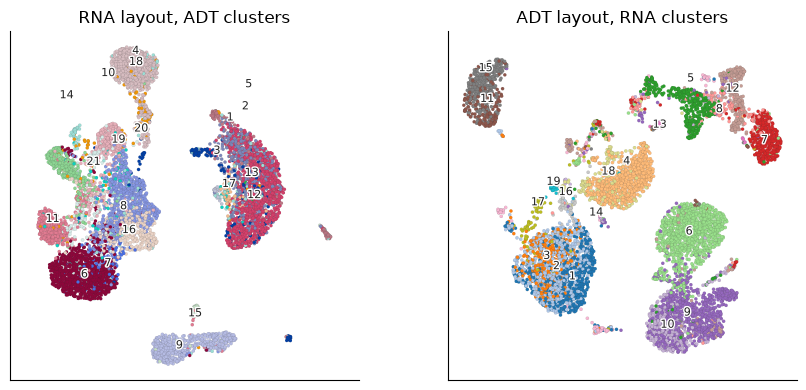

Started: 2026-10-08T13:05:18.493311Z | Wall time: 2.061 s

In [3]:
# Create axes for the comparison panels.
figure, axes = plt.subplots(1, 2, figsize=(9, 4))

# Draw each result on its comparison axes.
for axis, layout, labels, title in (
    (axes[0], rna_run["umap"], adt_clusters, "RNA layout, ADT clusters"),
    (axes[1], adt_layout, rna_run["clusters"], "ADT layout, RNA clusters"),
):

    # Color each assay's layout by clusters from the other assay.
    ds.plots.embedding(
        layout=layout,
        color_by=labels,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )

    # Label the panel with the result it shows.
    axis.set_title(title)

# Adjust spacing between the comparison panels.
figure.tight_layout()

Broad agreement supports a shared population structure. Local differences are not automatically
errors: protein abundance and RNA expression can differ, and protein can resolve a population
whose transcript is sparse. Investigate large contradictory regions before integration, using
markers and assay quality to distinguish complementary biology from technical problems.

## Inspect WNN modality weights

Where does each assay contribute most strongly to the integrated graph? Open the WNN graph
and the layout made from it:

In [4]:
# Select the saved WNN graph; require exactly one match.
wnn_graph = ds.artifacts.find("graph", method="wnn")

# Select the saved WNN layout; require exactly one match.
wnn_layout = ds.artifacts.find("embedding", graph=wnn_graph, method="umap")

# Inspect the WNN layout associated with the selected graph.
wnn_layout

ArtifactRef(datastore, kind='embedding', artifact_id='3d0b3b9746b5...')

Started: 2026-10-08T13:05:20.560067Z | Wall time: 0.026 s

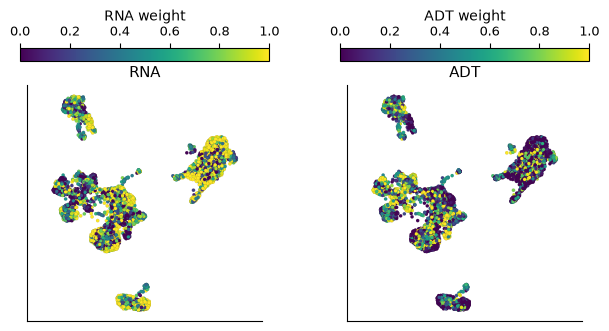

Started: 2026-10-08T13:05:20.590624Z | Wall time: 1.094 s

In [5]:
# Show how much each modality contributes across the joint map.
ds.plots.modality_weights(graph=wnn_graph, layout=wnn_layout)

Spatial shifts show where RNA or ADT contributes more strongly. Check unexpected shifts
against markers and assay quality; noisy features or retained control antibodies can also
change the weights.

## Compare WNN with SNN

SNN merges connectivity maps with equal standing. WNN consumes neighbour artifacts and learns a
per-cell contribution for each modality. Both preserve their exact source references; neither
becomes an implicit active graph.

Open the SNN result only when making this comparison:

In [6]:
# Select the saved SNN graph; require exactly one match.
snn_graph = ds.artifacts.find("graph", method="snn")

# Select the saved SNN layout; require exactly one match.
snn_layout = ds.artifacts.find("embedding", graph=snn_graph, method="umap")

# Inspect the SNN layout associated with the selected graph.
snn_layout

ArtifactRef(datastore, kind='embedding', artifact_id='ada3a9cd9367...')

Started: 2026-10-08T13:05:21.688564Z | Wall time: 0.031 s

Retrieve the cluster labels from each integrated graph:

In [7]:
# Select the saved SNN clusters; require exactly one match.
snn_clusters = ds.artifacts.find("clusters", graph=snn_graph, method="leiden")

# Select the saved WNN clusters; require exactly one match.
wnn_clusters = ds.artifacts.find("clusters", graph=wnn_graph, method="leiden")

# Inspect the two clusterings selected for comparison.
{"SNN clusters": snn_clusters, "WNN clusters": wnn_clusters}

{'SNN clusters': ArtifactRef(datastore, kind='cluster_labels', artifact_id='bb75f57b0f17...'),
 'WNN clusters': ArtifactRef(datastore, kind='cluster_labels', artifact_id='cbdf7519e896...')}

Started: 2026-10-08T13:05:21.725190Z | Wall time: 0.025 s

### Which integration preserves CD16 protein geography better?

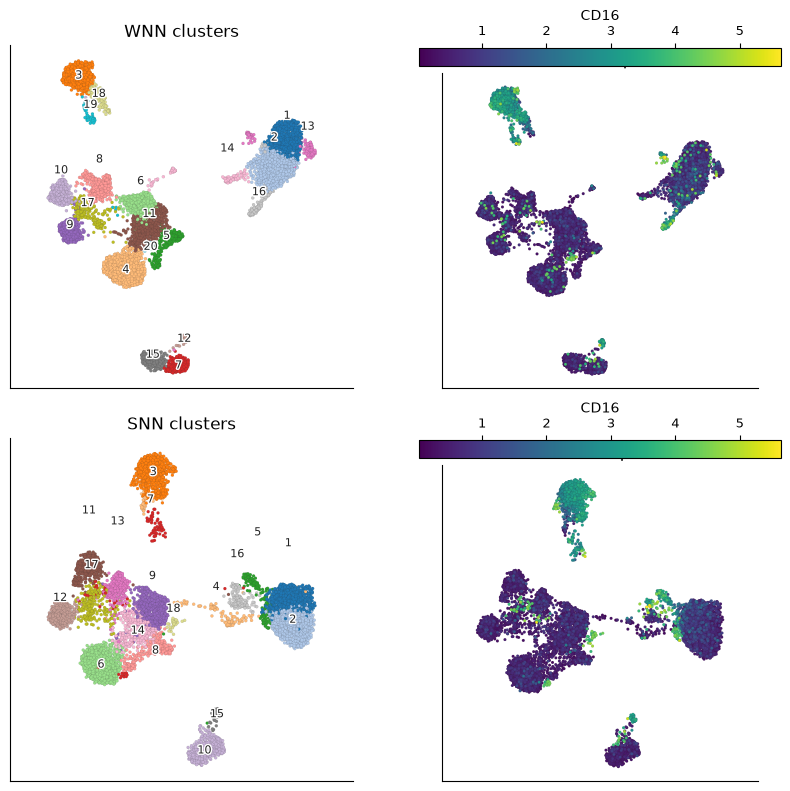

Started: 2026-10-08T13:05:21.755211Z | Wall time: 5.868 s

In [8]:
# Select the CD16 protein measurement by its feature identifier.
cd16 = FeatureRef("CD16", assay="ADT", by="id", label="CD16")

# Create axes for the comparison panels.
figure, axes = plt.subplots(2, 2, figsize=(9, 8))

# Draw each result on its comparison axes.
for row, layout, labels, method in (
    (0, wnn_layout, wnn_clusters, "WNN"),
    (1, snn_layout, snn_clusters, "SNN"),
):

    # Show the clusters on this integration's own layout.
    ds.plots.embedding(
        layout=layout,
        color_by=labels,
        legend_loc="on_data",
        show_titles=False,
        target=axes[row, 0],
        show=False,
    )

    # Label the panel with the result it shows.
    axes[row, 0].set_title(f"{method} clusters")

    # Show CD16 protein on the same integration layout.
    ds.plots.embedding(
        layout=layout,
        color_by=cd16,
        sort_values=True,
        show_titles=False,
        target=axes[row, 1],
        show=False,
    )

    # Label the panel with the result it shows.
    axes[row, 1].set_title(f"{method}: CD16 protein")

# Adjust spacing between the comparison panels.
figure.tight_layout()

The marker should remain localized rather than being spread across unrelated integrated groups.
Use several markers and known populations in a real study; one visually compact layout is not a
selection criterion.

Partition concordance quantifies similarity without declaring a winner:

In [9]:
# Collect the four clusterings to compare.
partitions = {
    "RNA": rna_run["clusters"],
    "ADT": adt_clusters,
    "SNN": snn_clusters,
    "WNN": wnn_clusters,
}

# Collect one agreement summary per pair of clusterings.
concordance = []

# Compare each pair of clusterings once.
for first, second in combinations(partitions, 2):

    # Measure agreement with the adjusted Rand index.
    ari = ds.clusters.compute_concordance(partitions[first], partitions[second], metric="ari")

    # Measure agreement with normalized mutual information.
    nmi = ds.clusters.compute_concordance(partitions[first], partitions[second], metric="nmi")

    # Keep both agreement measures with the comparison name.
    concordance.append({"comparison": f"{first} vs {second}", "ARI": ari, "NMI": nmi})

# Display agreement scores for each pair of clusterings.
pd.DataFrame(concordance)

,comparison,ARI,NMI
0,RNA vs ADT,0.589905,0.683815
1,RNA vs SNN,0.656173,0.773921
2,RNA vs WNN,0.754323,0.830901
3,ADT vs SNN,0.725142,0.789331
4,ADT vs WNN,0.649658,0.745831
5,SNN vs WNN,0.770778,0.850922


Started: 2026-10-08T13:05:27.631684Z | Wall time: 0.541 s

The adjusted Rand index (ARI) compares which cell pairs the two partitions place together or
apart, correcting for chance agreement. An ARI of 1 means identical partitions; values near
0 indicate chance-level agreement, and negative values can occur. Normalized mutual information
(NMI) measures how much knowing one partition's labels tells us about the other. It ranges from
0 to 1 but is not corrected for chance. Both ignore the names assigned to clusters, and neither
tells us which partition is biologically correct. Interpret them alongside markers and assay
design instead of trying to maximize the scores.

## Choose and validate an integration

### Choosing WNN or SNN

- **WNN adapts to local information.** It can be useful when ADT separates some populations
  clearly while RNA resolves populations that the antibody panel does not cover. Its weights
  describe the relative contribution of each modality for each cell; inspect whether those
  contributions agree with the measurements and the panel design.
- **SNN provides an equal-standing comparison.** Use it when you want to combine the graphs
  without learned cell-specific modality weights. Comparing it with WNN helps identify
  structures that depend strongly on one modality's contribution.

### Checks to make before interpreting the joint graph

- **Inspect modality weights.** Local shifts can reflect complementary information, such as
  strong ADT separation among lymphocytes. If one modality dominates across most cells,
  inspect normalization, technical dropout, feature selection, and the antibody panel's
  coverage. There is no universal weight cutoff that establishes a failed assay.
- **Overlay several markers.** Compare CD16 with other markers relevant to your populations,
  such as CD4 and CD19 when they are measured. Investigate unexpected mixing of populations
  using both the expression data and the graph, since a compact UMAP alone does not validate
  an integration.
- **Interpret partition agreement in context.** Different cluster numbers, complementary
  biology, and assay quality all affect ARI and NMI. There is no fixed ARI range that proves
  success. If agreement is unexpectedly low, check cell alignment, batch effects, and markers
  before interpreting it as biology.

### When the integration needs more work

Ambient ADT background or nonspecific antibody binding can connect unrelated cells. Uncorrected
batch effects in either assay can also shape the integrated graph. If distinct lineages appear
to collapse together, revisit those technical explanations and the neighbour parameters before
accepting either integration. Changing the integration method alone may not address the cause.

See [](batch_correction.ipynb) for a worked correction workflow,
[Integration and metrics API reference](/api/integration.html) for algorithm and input contracts,
and [](reuse_and_tracing.ipynb) for tracing the results you compare.